<a href="https://colab.research.google.com/github/sanjananagendra16-cpu/Advanced-Machine-Learning/blob/main/AML_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost lightgbm -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import PassiveAggressiveClassifier, RidgeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

train_df.head()

Training Shape: (29972, 3)
Testing Shape: (7600, 3)


,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [5]:
print("Training Dataset Information:")
print(train_df.info())

print("\nMissing Values:")
print(train_df.isnull().sum())

print("\nClass Distribution:")
print(train_df.iloc[:, 0].value_counts())

Training Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29972 entries, 0 to 29971
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  29972 non-null  int64 
 1   Title        29972 non-null  object
 2   Description  29971 non-null  object
dtypes: int64(1), object(2)
memory usage: 702.6+ KB
None

Missing Values:
Class Index    0
Title          0
Description    1
dtype: int64

Class Distribution:
Class Index
1    7795
4    7779
2    7355
3    7043
Name: count, dtype: int64


In [6]:
train_df.columns = ["Class_Index", "Title", "Description"]
test_df.columns = ["Class_Index", "Title", "Description"]

print(train_df.head())

   Class_Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  


In [7]:
train_df["Text"] = (
    train_df["Title"].fillna("") + " " +
    train_df["Description"].fillna("")
)

test_df["Text"] = (
    test_df["Title"].fillna("") + " " +
    test_df["Description"].fillna("")
)

train_df[["Text", "Class_Index"]].head()

,Text,Class_Index
0,Wall St. Bears Claw Back Into the Black (Reute...,3
1,Carlyle Looks Toward Commercial Aerospace (Reu...,3
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,3
3,Iraq Halts Oil Exports from Main Southern Pipe...,3
4,"Oil prices soar to all-time record, posing new...",3


In [8]:
X_train_text = train_df["Text"]
y_train = train_df["Class_Index"]

X_test_text = test_df["Text"]
y_test = test_df["Class_Index"]

print("Training Samples:", len(X_train_text))
print("Testing Samples:", len(X_test_text))

Training Samples: 29972
Testing Samples: 7600


In [9]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF Training Shape:", X_train.shape)
print("TF-IDF Testing Shape:", X_test.shape)

TF-IDF Training Shape: (29972, 20000)
TF-IDF Testing Shape: (7600, 20000)


In [10]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

print("Original Classes:", sorted(y_train.unique()))
print("XGBoost Classes:", sorted(y_train_xgb.unique()))

Original Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
XGBoost Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [11]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train_xgb)

xgb_pred = xgb_model.predict(X_test) + 1

print("XGBoost training completed.")

XGBoost training completed.


In [12]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted")
xgb_recall = recall_score(y_test, xgb_pred, average="weighted")
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

print("XGBoost Results")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost Results
Accuracy : 0.8282
Precision: 0.8306
Recall   : 0.8282
F1 Score : 0.8285

Classification Report:
              precision    recall  f1-score   support

           1       0.85      0.83      0.84      1900
           2       0.89      0.88      0.88      1900
           3       0.83      0.77      0.80      1900
           4       0.75      0.84      0.79      1900

    accuracy                           0.83      7600
   macro avg       0.83      0.83      0.83      7600
weighted avg       0.83      0.83      0.83      7600



In [13]:
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(X_train, y_train_xgb)

lgbm_pred = lgbm_model.predict(X_test) + 1

print("LightGBM training completed.")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM training completed.


In [14]:
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, average="weighted")
lgbm_recall = recall_score(y_test, lgbm_pred, average="weighted")
lgbm_f1 = f1_score(y_test, lgbm_pred, average="weighted")

print("LightGBM Results")
print("Accuracy :", round(lgbm_accuracy, 4))
print("Precision:", round(lgbm_precision, 4))
print("Recall   :", round(lgbm_recall, 4))
print("F1 Score :", round(lgbm_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, lgbm_pred))

LightGBM Results
Accuracy : 0.8784
Precision: 0.8786
Recall   : 0.8784
F1 Score : 0.8782

Classification Report:
              precision    recall  f1-score   support

           1       0.89      0.87      0.88      1900
           2       0.92      0.95      0.93      1900
           3       0.87      0.82      0.84      1900
           4       0.83      0.87      0.85      1900

    accuracy                           0.88      7600
   macro avg       0.88      0.88      0.88      7600
weighted avg       0.88      0.88      0.88      7600



In [15]:
extra_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(X_train, y_train)

extra_pred = extra_model.predict(X_test)

print("Extra Trees training completed.")

Extra Trees training completed.


In [16]:
extra_accuracy = accuracy_score(y_test, extra_pred)
extra_precision = precision_score(y_test, extra_pred, average="weighted")
extra_recall = recall_score(y_test, extra_pred, average="weighted")
extra_f1 = f1_score(y_test, extra_pred, average="weighted")

print("Extra Trees Results")
print("Accuracy :", round(extra_accuracy, 4))
print("Precision:", round(extra_precision, 4))
print("Recall   :", round(extra_recall, 4))
print("F1 Score :", round(extra_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, extra_pred))

Extra Trees Results
Accuracy : 0.8725
Precision: 0.8723
Recall   : 0.8725
F1 Score : 0.8719

Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.88      0.89      1900
           2       0.91      0.96      0.93      1900
           3       0.86      0.80      0.83      1900
           4       0.83      0.85      0.84      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



In [17]:
pa_model = PassiveAggressiveClassifier(
    max_iter=1000,
    random_state=42
)

pa_model.fit(X_train, y_train)

pa_pred = pa_model.predict(X_test)

print("Passive Aggressive training completed.")

Passive Aggressive training completed.


In [18]:
pa_accuracy = accuracy_score(y_test, pa_pred)
pa_precision = precision_score(y_test, pa_pred, average="weighted")
pa_recall = recall_score(y_test, pa_pred, average="weighted")
pa_f1 = f1_score(y_test, pa_pred, average="weighted")

print("Passive Aggressive Results")
print("Accuracy :", round(pa_accuracy, 4))
print("Precision:", round(pa_precision, 4))
print("Recall   :", round(pa_recall, 4))
print("F1 Score :", round(pa_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, pa_pred))

Passive Aggressive Results
Accuracy : 0.8532
Precision: 0.8533
Recall   : 0.8532
F1 Score : 0.8532

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.86      0.86      1900
           2       0.93      0.93      0.93      1900
           3       0.81      0.79      0.80      1900
           4       0.81      0.84      0.82      1900

    accuracy                           0.85      7600
   macro avg       0.85      0.85      0.85      7600
weighted avg       0.85      0.85      0.85      7600



In [19]:
ridge_model = RidgeClassifier()

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge Classifier training completed.")

Ridge Classifier training completed.


In [20]:
ridge_accuracy = accuracy_score(y_test, ridge_pred)
ridge_precision = precision_score(y_test, ridge_pred, average="weighted")
ridge_recall = recall_score(y_test, ridge_pred, average="weighted")
ridge_f1 = f1_score(y_test, ridge_pred, average="weighted")

print("Ridge Classifier Results")
print("Accuracy :", round(ridge_accuracy, 4))
print("Precision:", round(ridge_precision, 4))
print("Recall   :", round(ridge_recall, 4))
print("F1 Score :", round(ridge_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, ridge_pred))

Ridge Classifier Results
Accuracy : 0.8943
Precision: 0.8949
Recall   : 0.8943
F1 Score : 0.8941

Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.88      0.90      1900
           2       0.94      0.97      0.96      1900
           3       0.87      0.83      0.85      1900
           4       0.84      0.90      0.87      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89      7600
weighted avg       0.89      0.89      0.89      7600



In [21]:
results = pd.DataFrame({
    "Algorithm": [
        "XGBoost",
        "LightGBM",
        "Extra Trees",
        "Passive Aggressive",
        "Ridge Classifier"
    ],

    "Accuracy": [
        xgb_accuracy,
        lgbm_accuracy,
        extra_accuracy,
        pa_accuracy,
        ridge_accuracy
    ],

    "Precision": [
        xgb_precision,
        lgbm_precision,
        extra_precision,
        pa_precision,
        ridge_precision
    ],

    "Recall": [
        xgb_recall,
        lgbm_recall,
        extra_recall,
        pa_recall,
        ridge_recall
    ],

    "F1 Score": [
        xgb_f1,
        lgbm_f1,
        extra_f1,
        pa_f1,
        ridge_f1
    ]
})

results.round(4)

,Algorithm,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.8282,0.8306,0.8282,0.8285
1,LightGBM,0.8784,0.8786,0.8784,0.8782
2,Extra Trees,0.8725,0.8723,0.8725,0.8719
3,Passive Aggressive,0.8532,0.8533,0.8532,0.8532
4,Ridge Classifier,0.8943,0.8949,0.8943,0.8941


In [22]:
best_algorithm = results.loc[
    results["F1 Score"].idxmax()
]

print("Best Performing Algorithm:")
print(best_algorithm)

Best Performing Algorithm:
Algorithm    Ridge Classifier
Accuracy             0.894342
Precision            0.894851
Recall               0.894342
F1 Score             0.894064
Name: 4, dtype: object


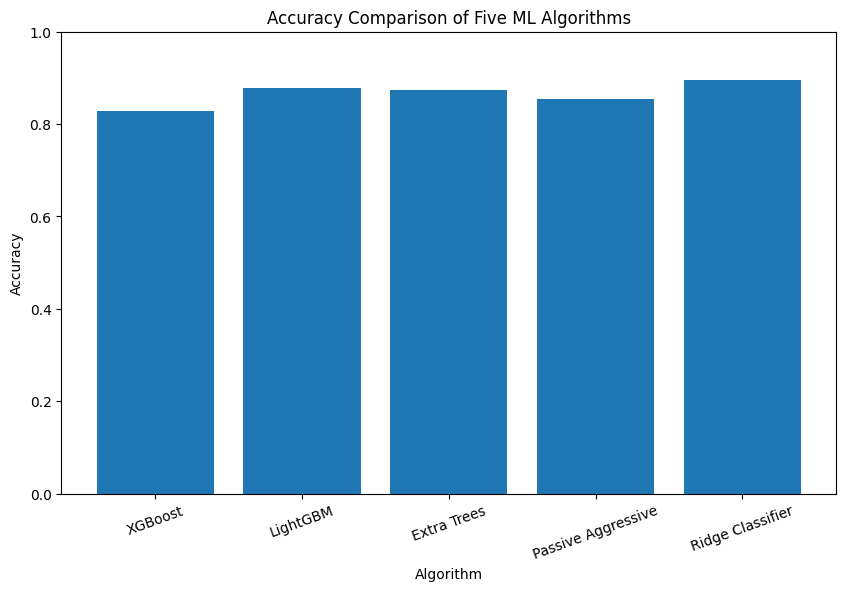

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["Accuracy"]
)

plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Five ML Algorithms")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

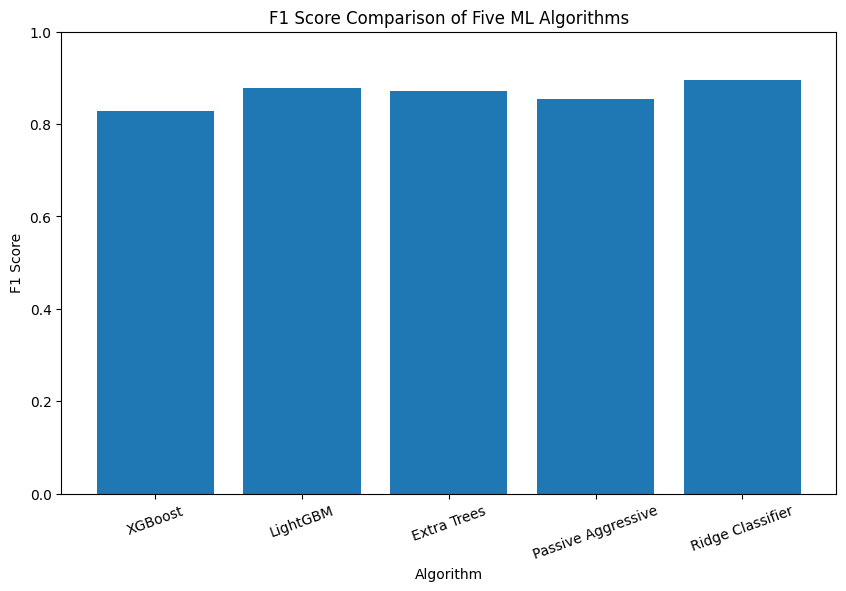

In [24]:
plt.figure(figsize=(10, 6))

plt.bar(
    results["Algorithm"],
    results["F1 Score"]
)

plt.xlabel("Algorithm")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Five ML Algorithms")
plt.xticks(rotation=20)
plt.ylim(0, 1)

plt.show()

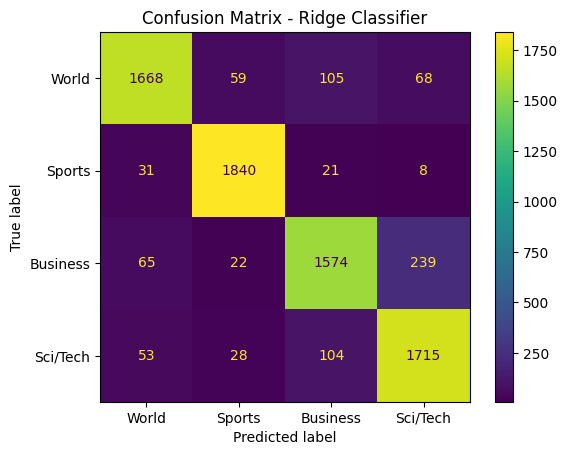

In [25]:
best_name = best_algorithm["Algorithm"]

predictions = {
    "XGBoost": xgb_pred,
    "LightGBM": lgbm_pred,
    "Extra Trees": extra_pred,
    "Passive Aggressive": pa_pred,
    "Ridge Classifier": ridge_pred
}

best_pred = predictions[best_name]

cm = confusion_matrix(y_test, best_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "World",
        "Sports",
        "Business",
        "Sci/Tech"
    ]
)

disp.plot()

plt.title("Confusion Matrix - " + best_name)
plt.show()